# Toy models: latent sensitivity to small input perturbations

Measures how far the latent point moves when the input spectrum is moved by a controlled Fisher--Rao distance, which is the local sensitivity the contractive term penalizes. It answers whether the contractive variants turn the same input perturbation into a smaller rotation on the sphere.

## Introduction

The toy campaign (`kidney-representative-toy-circle`) trains cumulative objectives on one small kidney image with latent width $L = 3$, so that the whole latent space is $S^1$ and can be shown directly. Its figures are used in the conceptual presentation (`assets/documents/prestentations/segmentation_model_full_conceptual`).

### Assumptions

- One model per objective (one repetition). Differences between variants are single realizations, not
  estimates of an expected effect; the toy is illustrative, not a benchmark.
- All variants share the data split, the initialization seed and the training seed, so the only
  difference is the objective.
- Architecture, optimizer, loss parameters and loss weights follow the `real_only` schedule of the
  `20_09_26_metaspace_base_pretrain` campaign (without label-weighted contrastive negatives), including
  its 10 epochs; only `latent_dim` is smaller.
- Ten epochs on the training part of 16 230 pixels are about 2000 optimizer steps; the
  auxiliary terms (weights 0.2, 0.001, 0.002) contribute little to the objective, so differences between
  variants are expected to be small.
- Display categories are built from five selected ions (three spatially disjoint, one overlapping one of
  them, one present almost everywhere) by the rules in `analysis_settings.yaml`; names list the ions.

### Notation

| symbol | meaning |
|---|---|
| $x \in \Delta^{M-1}$ | TIC-normalized binned spectrum, $M = 1364$ bins of $0.55$ m/z on $[200, 950]$ |
| $a \in \mathbb{R}^{L}$ | encoder output before the bottleneck `LayerNorm`, $L = 3$ |
| $u = (a - \mu_a \mathbf 1)/\sigma_a$ | canonical latent, $\mathbf 1^\top u = 0$, $\lVert u \rVert = \sqrt L$ |
| $z = \gamma \odot u + \beta$ | model latent (affine `LayerNorm` output) |
| $s = Q^\top u / \lVert Q^\top u \rVert \in S^1$ | latent coordinates; $Q \in \mathbb{R}^{3 \times 2}$ fixed orthonormal basis of $\mathbf 1^\perp$ |
| $\mathcal M_0, \dots, \mathcal M_4$ | objectives: reconstruction; + head; + head + contrastive; + head + contractive; + head + both |
| $\angle(u, u')$ | angle between canonical latents, in degrees |

## Configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import representative_toy_precompute as toy
from msi_autoencoder_wrapper.visualization import representative_toy as viz

SETTINGS = toy.load_settings(Path("analysis_settings.yaml"))
FIGURES = Path(SETTINGS["repository_root"]) / SETTINGS["figures"]["presentation_directory"]
LABELS = SETTINGS["campaign"]["labels"]
SHOWN = SETTINGS["campaign"]["presentation"]  # variants used on the slides
PREFIX = SETTINGS["figures"]["prefix"]
REGION_COLORS = {rule["name"]: rule["color"] for rule in SETTINGS["regions"]}

classes = toy.load_table(SETTINGS, "dataset", "classes")
pixels = toy.load_table(SETTINGS, "dataset", "pixels")
pixels["region"] = toy.assign_regions(pixels, classes, SETTINGS["regions"])

2026-09-24 02:36:12,970 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-24 02:36:12,974 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-24 02:36:13,393 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-24 02:36:13,395 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 28 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-24 02:36:13,421 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-24 02:36:13,422 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 46 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-24 02:36:13,456 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-09-24 02:36:13,473 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-09-24 02:36:13,475 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 33 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Producing the tables this notebook reads

The tables are written by the toy precomputation module; the command below is generated by that module.

In [2]:
print(toy.run_command(SETTINGS, "sensitivity"))

nohup /home/max/repositories/MSIAutoEncoderWrapper/.venv/bin/python -m msi_autoencoder_wrapper.analysis.autoencoder.experiments.representative_toy_precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/representative_model/24_09_26_toy_presentation_circle/analysis_settings.yaml --analysis sensitivity > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/representative_model/24_09_26_toy_presentation_circle/precompute.log 2>&1 &


## Latent angle as a function of the Fisher--Rao perturbation size

### Methodology

#### Theoretical

With $r = \sqrt{x}$ on the unit sphere and a random unit tangent $t \perp r$, the perturbed spectrum $x' = (\cos\theta\, r + \sin\theta\, t)^2$ lies on the simplex at Fisher--Rao distance $d_{FR}(x, x') = 2\theta$. The response is $\angle(u(x), u(x'))$; its slope at small $\theta$ is the local sensitivity controlled by the contractive penalty in the same geometry.

#### Implementation

Five geodesic half-angles, 16 random directions per pixel and angle, identical random directions for all variants (the generator is re-seeded per variant). The summary is the median and interquartile range over all pixels and directions.

#### Figure descriptions

x = Fisher--Rao distance $2\theta$, y = latent angle in degrees; line = median, band = interquartile range; colour = variant. Lower curves mean a less sensitive encoder.

In [3]:
angles = toy.load_table(SETTINGS, "sensitivity", "angles")
summary = (angles.groupby(["variant", "fisher_rao_distance"], sort=False).latent_angle_deg
           .agg(median="median", q25=lambda v: v.quantile(0.25), q75=lambda v: v.quantile(0.75)).reset_index())
display(summary.pivot(index="fisher_rao_distance", columns="variant", values="median").round(2))

variant,m0-reconstruction,m1-head,m2-head-contrastive,m3-head-contractive,m4-head-contrastive-contractive
fisher_rao_distance,,,,,
0.04,0.05,0.05,0.05,0.06,0.06
0.10,0.14,0.13,0.13,0.15,0.14
0.20,0.27,0.27,0.25,0.30,0.28
0.40,0.55,0.55,0.51,0.60,0.56
0.60,0.84,0.83,0.78,0.92,0.86


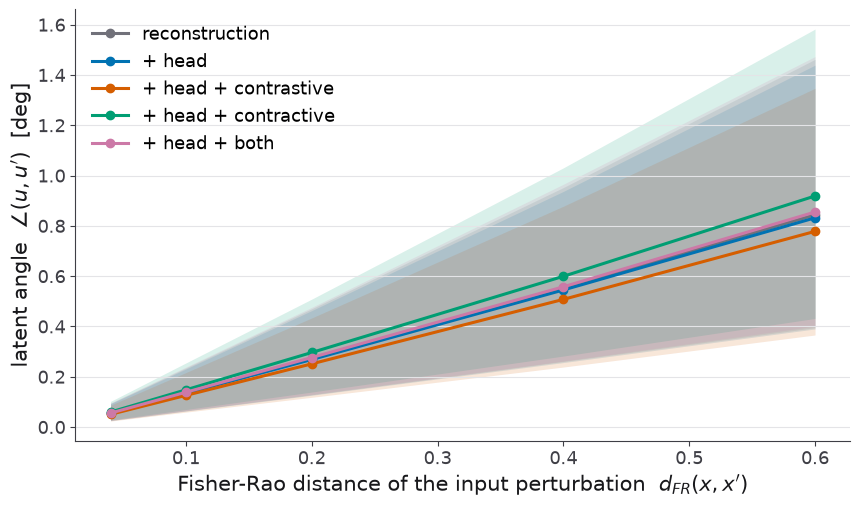

In [4]:
with viz.presentation_style():
    figure = viz.plot_angle_curves(summary, x="fisher_rao_distance", labels=LABELS,
                                   xlabel="Fisher-Rao distance of the input perturbation  $d_{FR}(x, x')$")
    viz.save_figure(figure, FIGURES, PREFIX + "contractive_curves")
    plt.show()

### Remarks

### Notes

## Perturbation clouds of selected pixels

### Methodology

#### Theoretical

For one pixel per annotated region, many perturbations of the same size are mapped to the sphere; the spread of the cloud around the original point visualizes the local sensitivity.

#### Implementation

Display pixels are chosen in the precomputation (pixel nearest to the spatial centroid of each region); 96 directions at $\theta = 0.3$ ($d_{FR} = 0.6$).

#### Figure descriptions

One sphere per variant (+ head against + head + contractive, then + head against + head + both); large outlined points = original pixels, small points = perturbed copies; colour = category of the pixel.

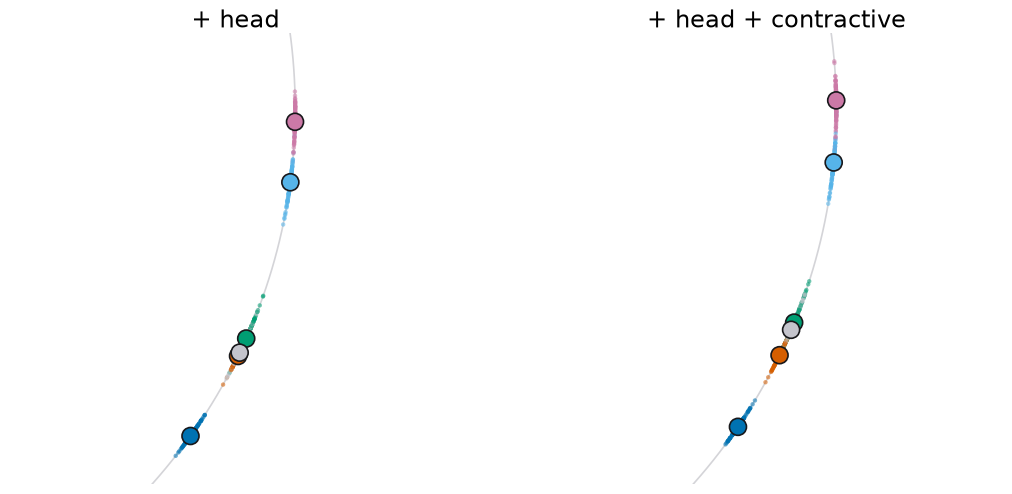

In [5]:
cloud = toy.load_table(SETTINGS, "sensitivity", "display_cloud")
region_of = dict(zip(pixels.source_id, pixels.region))
variants = ["m1-head", SHOWN["contractive"]]
with viz.presentation_style():
    figure = viz.plot_perturbation_clouds([(LABELS[v], cloud[cloud.variant == v]) for v in variants], region_of, REGION_COLORS)
    viz.save_figure(figure, FIGURES, PREFIX + "contractive_clouds")
    plt.show()

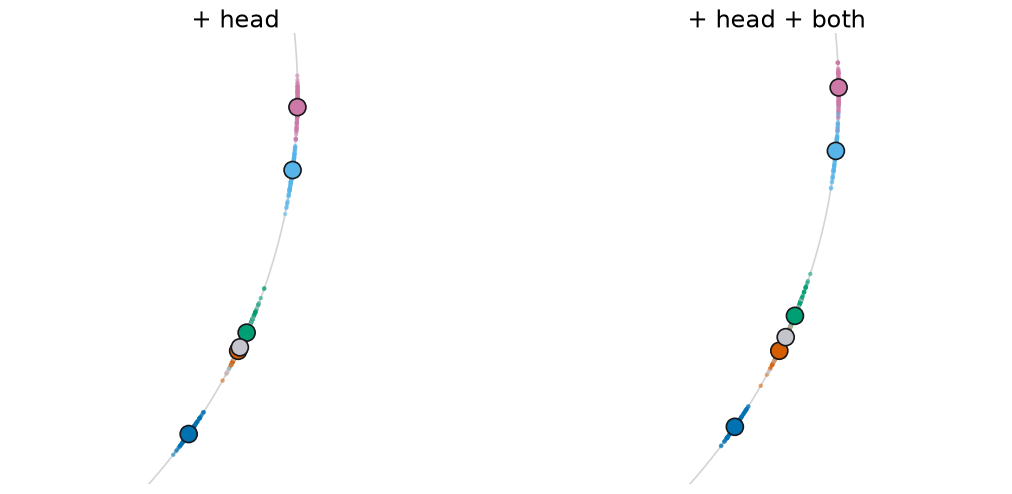

In [6]:
with viz.presentation_style():
    figure = viz.plot_perturbation_clouds([(LABELS[v], cloud[cloud.variant == v]) for v in ("m1-head", SHOWN["both"])], region_of, REGION_COLORS)
    viz.save_figure(figure, FIGURES, PREFIX + "contractive_clouds_both")
    plt.show()

### Remarks

### Notes

## Results / Summary

### LLM

### Person